In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import h5py, os, pickle

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm
from icecream import ic
from trianglechain import TriangleChain

from msfm.utils import logger, files, scales, power_spectra, parameters, observation
from msi.utils import preprocessing, dataset, input_output
from deep_lss.utils import configuration

# v15

In [29]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v15/extended.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v15/extended"

out_dir_base = "/pscratch/sd/a/athomsen/run_files/v15"
# label = "baseline"
# label = "baseline"
# label = "mmd"
# label = "cov"
# label = "sw_64"
label = "sw_penultimate_10"

### lensing

In [30]:
with_lensing = True
with_clustering = False
with_cross_z = False
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

dlss_conf = configuration.load_deep_lss_config(
    f"/global/u2/a/athomsen/y3-deep-lss/configs/v15/default/lensing/dlss.yaml"
)

26-02-03 05:44:07 configuratio INF   Loaded the config 


### clustering

In [31]:
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v15/default/clustering/dlss.yaml"
# )

### combined

In [32]:
# with_lensing = True
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# mocks = []

# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v15/default/combined/dlss.yaml"
# )

# constants

In [33]:
batch_size = 2**10
# batch_size = 2**6
apply_log = True
standardize = False

n_steps = 100_000

out_dir = os.path.join(out_dir_base, "cls/mutual_info/debug")
    
if label is not None:
    out_dir = os.path.join(out_dir, label)
    
os.makedirs(out_dir, exist_ok=True)

print("base_dir = ", base_dir)
print("out_dir = ", out_dir)

base_dir =  /pscratch/sd/a/athomsen/v11desy3/v15/extended
out_dir =  /pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/sw_penultimate_10


# white noise dset

26-02-03 05:44:08 configuratio INF   Loaded the config 
26-02-03 05:44:08 preprocessin INF   Using theta_fwhm = [29.5, 20.1, 15.0, 12.6, 130.2, 88.9, 68.1, 57.0] from the dlss config 
26-02-03 05:44:08 preprocessin INF   Using white_noise_sigma = [0.00030275, 0.00040448, 0.00048782, 0.00052049, 0.85135, 0.34375, 0.25989, 0.24127] from the dlss config 
26-02-03 05:44:08 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  82.94930876
 121.4848144  158.59030837 189.47368421] from the dlss config 
26-02-03 05:44:08 preprocessin INF   Using l_mins = [0. 0. 0. 0. 0. 0. 0. 0.] by default (no smoothing) 
26-02-03 05:44:08 preprocessin INF   Using n_bins = 33 from the msfm config 
26-02-03 05:44:08 preprocessin INF   Loading the pre-binned Cls 
26-02-03 05:44:08 input_output INF   Loading summaries from /pscratch/sd/a/athomsen/v11desy3/v15/extended 
26-02-03 05:44:08 input_output INF   Array shapes: 
26-02-03 05:44:08 input_output INF   fiducial/i_example = (

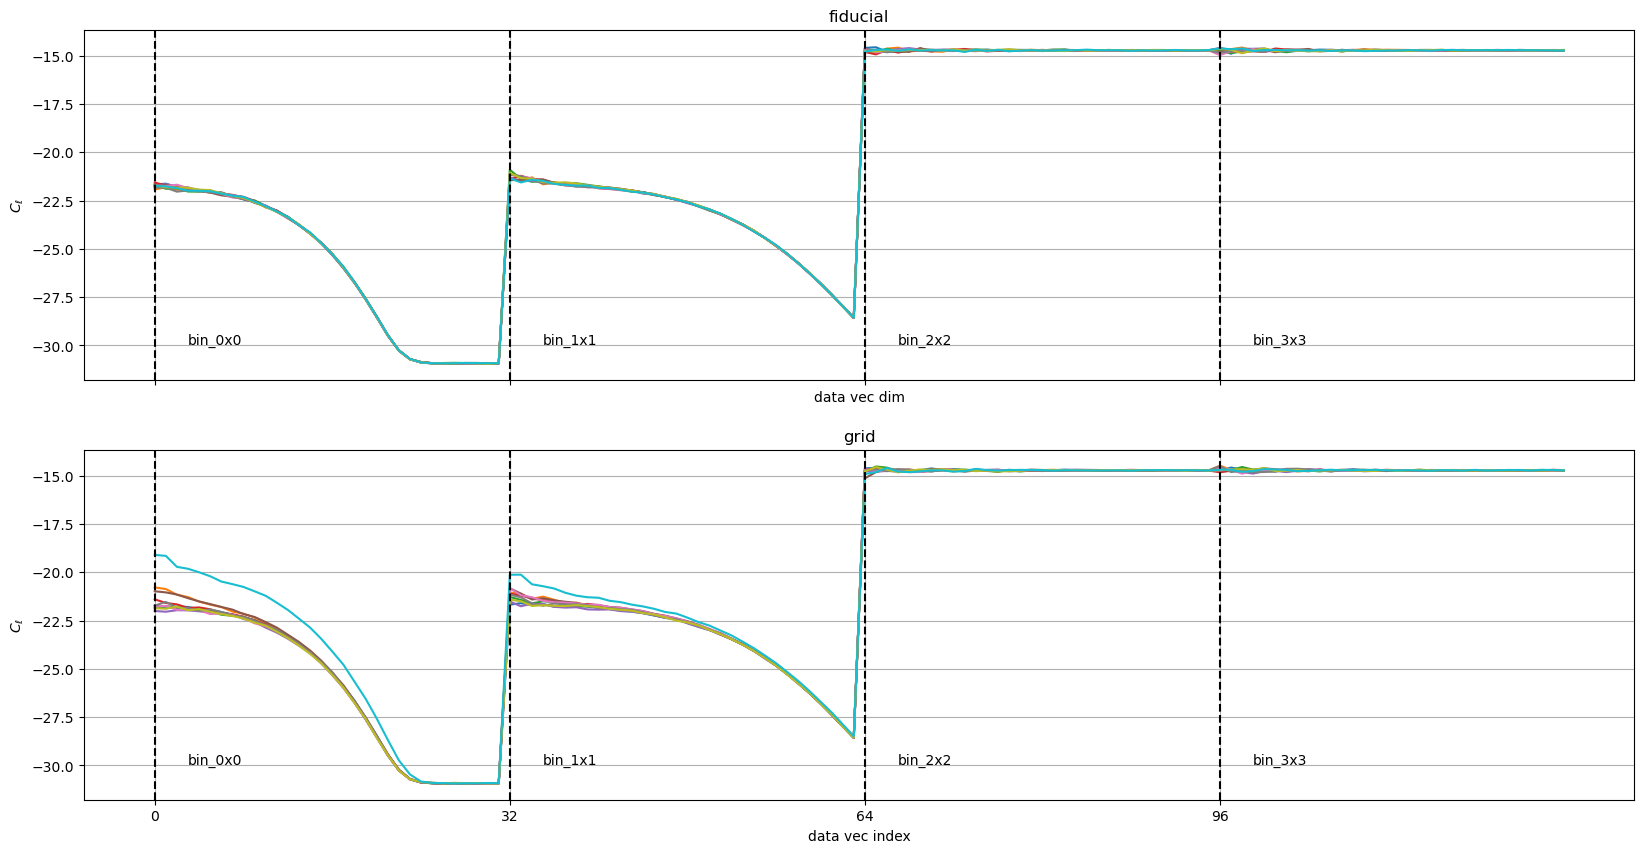

In [34]:
cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_gaussian_noise=True,
    # dset
    batch_size=batch_size,
    apply_log=True,
    standardize=False,
)

# functions and global constants

In [35]:
from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization
from deep_lss.nets.mlp import MultiLayerPerceptron

In [36]:
n_cls = out_dict["grid/cls/train"].shape[-1]
n_params = len(params)
n_summary = n_params

num_hidden_units = 1024
num_penultimate = 64
num_layers = 2
# num_layers = 4
# dropout_rate = 0.1
dropout_rate = 0.0

def get_cl_summary_network(n_summary=n_summary):
    mlp = MultiLayerPerceptron(
        output_size=n_summary, 
        num_hidden_units=num_hidden_units, 
        num_layers=num_layers, 
        num_penultimate=num_penultimate,
        dropout_rate=dropout_rate
    )
    mlp.build((None, n_cls))
    mlp.summary()
    
    return mlp

In [37]:
def train_model(model, eval_every=None):
    do_validation = eval_every is not None
    
    train_losses = []
    train_steps = []
    vali_steps = []
    vali_losses = []
    for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(n_steps+1)), total=n_steps):
        train_losses.append(model.grid_train_step(cl_batch, cosmo_batch))
        train_steps.append(i)
        
        if do_validation and (i % eval_every == 0) and (i !=0):
            vali_loss = []
            for cl_batch, cosmo_batch in cl_dset_test:
                vali_loss.append(model.vali_loss_fn(model(cl_batch, training=False), cosmo_batch))
            vali_losses.append(np.mean(vali_loss))
            vali_steps.append(i)

    fig, ax = plt.subplots()
    ax.plot(train_steps[100:], train_losses[100:], label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend()
    
    if do_validation:
        print(f"final validation loss = {vali_losses[-1]}")
        
    model.save_model()

# variational lower bound

In [38]:
learning_rate = 1e-4
optimizer = tf.keras.optimizers.Adam(learning_rate)

summary_net = get_cl_summary_network()
    
model = GridLossModel(
    summary_net,
    n_side=None,
    indices=None,
    optimizer=optimizer,
    checkpoint_dir=os.path.join(out_dir, "model"),
    summary_dir=os.path.join(out_dir, "history"),
    # restore_checkpoint=True,
    restore_checkpoint=False,
    # z_bank_size=4*batch_size,
)

model.setup_grid_loss_step(
    batch_size=batch_size,
    dim_theta=n_params,
    loss="mutual_info",
    dim_x=n_cls,
    dim_summary=n_summary,
    mutual_info_estimator="variational",
    clip_by_global_norm=1.0,
    mutual_info_kwargs={"full_covariance": False},
    # feature regularization
    z_weight=10,
    z_type="sw",
    # z_type="mmd",
    # z_type="cov",
    z_layer="penultimate",
    # z_layer="last",
)

26-02-03 05:44:17       mlp.py INF   Including a penultimate layer in the MLP 
Model: "multi_layer_perceptron_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer_normalization_2 (Lay  multiple                  256       
 erNormalization)                                                
                                                                 
 dense_22 (Dense)            multiple                  132096    
                                                                 
 dense_23 (Dense)            multiple                  1049600   
                                                                 
 penultimate (Dense)         multiple                  65600     
                                                                 
 output (Dense)              multiple                  390       
                                                                 
Total params: 1247942 (4.76 M

In [ ]:
train_model(model, eval_every=n_steps//10)

  0%|          | 0/100000 [00:00<?, ?it/s]

26-02-03 05:44:20 grid_model.p WAR   Tracing grid_train_step 
26-02-03 05:44:20 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
26-02-03 05:44:20 base_model.p INF   Using Sliced Wasserstein loss for z regularization 
26-02-03 05:44:21 grid_model.p WAR   Tracing grid_train_step 
26-02-03 05:44:21 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
26-02-03 05:44:21 base_model.p INF   Using Sliced Wasserstein loss for z regularization 


 11%|█         | 10762/100000 [01:09<08:31, 174.52it/s] 

# save the results

In [19]:
fidu_cls = out_dict["fidu/cls"]
grid_cls = out_dict["grid/cls/test"]

fidu_preds = model(fidu_cls, training=False).numpy()
grid_preds = model(grid_cls, training=False).numpy()

# z_model = tf.keras.Sequential(model.network.layers[:-1])
# fidu_z = z_model(fidu_cls, training=False)
# grid_z = z_model(grid_cls, training=False)

pred_file = os.path.join(out_dir, "preds.h5")
with h5py.File(pred_file, "w") as f:
    f.create_dataset(name="grid/cosmos/test", data=out_dict["grid/cosmos/test"])
    
    f.create_dataset(name="grid/preds/test", data=grid_preds)
    f.create_dataset(name="fidu/preds", data=fidu_preds)
    
#     f.create_dataset(name="grid/z/test", data=grid_z)
#     f.create_dataset(name="fidu/z", data=fidu_z)

# print(f"Wrote to {pred_file}\n")

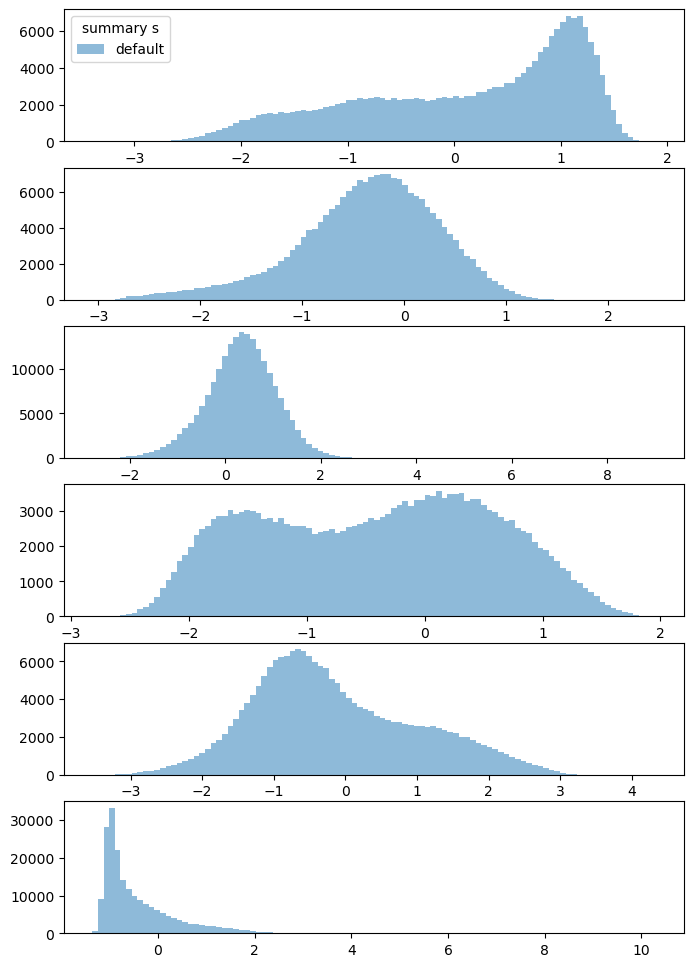

In [20]:
n_summary = grid_preds.shape[-1]

fig, ax = plt.subplots(figsize=(8,2*n_summary), nrows=n_summary)

for i in range(n_summary):
    ax[i].hist(grid_preds[:,i], bins=100, label="default", alpha=0.5)

ax[0].legend(title=f"summary s")

In [21]:
np.std(grid_preds, axis=0)**2

array([1.0706294 , 0.48370352, 0.5231914 , 0.95821154, 1.3286116 ,
       0.55330783], dtype=float32)

In [22]:
np.mean(grid_preds, axis=0)

array([ 0.12332065, -0.36323142,  0.32666507, -0.42395815, -0.14420034,
       -0.4355278 ], dtype=float32)

In [18]:
stop

NameError: name 'stop' is not defined

In [ ]:
plt.hist(

In [ ]:
stop

In [ ]:
grid_z.shape

In [ ]:
fig, ax = plt.subplots()

ax.hist(grid_z[:,14].numpy(), bins=100);

In [ ]:
np.cov(default_z, rowvar=False)

In [ ]:
mmd_z

# compare features

In [ ]:
# default_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/standard=False,log=True,steps=100000/testing/default/preds.h5"
# cov_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/standard=False,log=True,steps=100000/testing/with_z/preds.h5"
# mmd_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/standard=False,log=True,steps=100000/testing/with_z_mmd/preds.h5"

default_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/testing/standard=False,log=True,steps=100000/baseline/preds.h5"
cov_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/testing/standard=False,log=True,steps=100000/z_cov/preds.h5"
mmd_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/testing/standard=False,log=True,steps=100000/z_mmd/preds.h5"

with h5py.File(default_file, "r") as f:
    default_s = f["grid/preds/test"][:]
    default_z = f["grid/z/test"][:]
    
with h5py.File(cov_file, "r") as f:
    cov_s = f["grid/preds/test"][:]
    cov_z = f["grid/z/test"][:]

with h5py.File(mmd_file, "r") as f:
    mmd_s = f["grid/preds/test"][:]
    mmd_z = f["grid/z/test"][:]


In [ ]:
n_summary = default_s.shape[-1]

fig, ax = plt.subplots(figsize=(8,2*n_summary), nrows=n_summary)

for i in range(n_summary):
    ax[i].hist(default_s[:,i], bins=100, label="default", alpha=0.5)
    ax[i].hist(cov_s[:,i], bins=100, label="cov", alpha=0.5)
    ax[i].hist(mmd_s[:,i], bins=100, label="mmd", alpha=0.5)

ax[0].legend(title=f"summary s")

In [ ]:
n_z = default_z.shape[-1]
# n_z = 10

fig, ax = plt.subplots(figsize=(8,2*n_z), nrows=n_z)

for i in range(n_z):
    # ax[i].hist(default_z[:,i], bins=100, label="default", alpha=0.5)
    # ax[i].hist(cov_z[:,i], bins=100, label="cov", alpha=0.5)
    ax[i].hist(mmd_z[:,i], bins=100, label="mmd", alpha=0.5)

ax[0].legend(title=f"feature z")

In [ ]:
n_z = default_z.shape[-1]
# n_z = 10

fig, ax = plt.subplots(figsize=(8,2*n_z), nrows=n_z)

for i in range(n_z):
    # ax[i].hist(default_z[:,i], bins=100, label="default", alpha=0.5)
    # ax[i].hist(cov_z[:,i], bins=100, label="cov", alpha=0.5)
    ax[i].hist(mmd_z[:,i], bins=100, label="mmd", alpha=0.5)

ax[0].legend(title=f"feature z")